# Snapshot eval violins — held-out eval-config comparison across GEN snapshots

Compares **per-episode eval metrics** of several GEN snapshots across the **held-out eval
configs** their eval runs covered, drawn side by side at each config. A GEN eval run writes one
result directory per infra config; **only the held-out ones** — directory names ending in
`_eval_<i>` (e.g. `battery_lin_cap_eval_1`) — are used, training-config directories
(`battery_lin_cap_1..5`) are skipped.

The x-axis carries the eval configs (`eval_1`, `eval_2`, …); at each config the sources are
drawn as **dodged violins side by side** — one per snapshot — mirroring
`sps_eval_violins_seed_compare.ipynb`, which fans out over seeds instead. As configured here:
the four DreamerV3 runs of the battery-capacity generalisation trial (fixed 17 kWh, fixed
15 kWh, a 5-way capacity cycle, and per-episode capacity sampling) on the three held-out
capacities 12 / 16 / 22 kWh.

Each **source** is one snapshot evaluated under one eval kind (plus a rule-based strategy for
`eval-rbc`):

| `eval-kind` | Run directory pattern | Producer | Per-eval-config CSV | Seed metadata |
|---|---|---|---|---|
| `eval-ray` | `runs/eval_<ts>[_seed<N>]/` | Ray RLlib eval (`run_eval_ray.py`) | `eval_results/*_eval/<name>_eval_<i>/eval_*.csv` | sidecar JSON `"seed"` |
| `eval-sb` | `runs/eval_sb_<ts>[_seed<N>]/` | SB3 eval (`run_eval_sb.py`) | `eval_results/*_eval/<name>_eval_<i>/eval_*.csv` | sidecar JSON `"seed"` |
| `eval-rbc` | `runs/eval_rbc_<ts>[_seed<N>]/` | Rule-based eval (`run_eval_rule_based.py`) | `eval_results/*_rule_based/<strategy>/<name>_eval_<i>/episodes.csv` | `args.json` `"resolved_seed"` |

Every run's seed comes from its **own metadata**, never from the directory name. With
`SEEDS = None` a snapshot's whole `_seed<N>` fan-out pools into one violin per eval config;
a single seed (`SEEDS = 42`, as set here) or a list narrows that. Sources with no run on a
wanted seed drop out with a warning, leaving a gap in their x-axis slot.

**Main input:** `SOURCES`, `SEEDS`, `EXCLUDE_EVAL_CFGS` and the x-tick renaming
`EVAL_CFG_LABELS` in the next cell.

In [58]:
# --- Main input ---------------------------------------------------------------------
# The sources to compare side by side at each held-out eval config. Each source is one
# snapshot evaluated under one eval kind; at every eval config the x-axis draws one
# violin per source. Keys per entry:
#   path          snapshot dir (absolute, or relative to the repo root)
#   eval-kind     "eval-ray" | "eval-sb" | "eval-rbc" — which runs/eval_* dirs to use
#   label         short name shown in the legend and used as the per-config violin group
#   color         violin fill colour for this source
#   rbc-strategy  (eval-rbc only) which rule-based strategy to compare across configs

# SAC paths:
# snapshots/20260718_143913_gen_battery_lin_so_only_17kW_sac
# snapshots/20260718_144018_gen_battery_lin_so_only_15kW_sac
# snapshots/20260718_143903_gen_battery_lin_so_all_sac
# snapshots/20260718_173801_gen_battery_lin_capacity_sampled_sac

# PPO paths:
# snapshots/20260718_183913_gen_battery_lin_so_only_17kW_ppo
# snapshots/20260718_184018_gen_battery_lin_so_only_15kW_ppo
# snapshots/20260718_183903_gen_battery_lin_so_all_ppo
# snapshots/20260718_183801_gen_battery_lin_capacity_sampled_ppo

# Dreamer paths:
# snapshots/20260718_141113_gen_battery_lin_so_only_17kW_dreamerv3
# snapshots/20260718_141218_gen_battery_lin_so_only_15kW_dreamerv3
# snapshots/20260718_140503_gen_battery_lin_so_all_dreamerv3
# snapshots/20260716_175201_gen_battery_lin_capacity_sampled_dreamerv3

# Old dreamer paths:
# snapshots/20260714_225342_gen_battery_lin_so_only_15kW_dreamer
# snapshots/20260714_225444_gen_battery_lin_so_only_17kW_dreamer
# snapshots/20260714_225542_gen_battery_lin_so_all_dreamer_v2
# snapshots/20260714_225647_gen_battery_lin_capacity_sampled_dreamer

# snapshots/20260714_235444_gen_battery_lin_so_only_17kW_ppo
# snapshots/20260714_235342_gen_battery_lin_so_only_15kW_ppo
# snapshots/20260714_235542_gen_battery_lin_so_all_ppo_v2
# snapshots/20260714_235647_gen_battery_lin_capacity_sampled_ppo

# snapshots/20260714_161830_gen_battery_lin_so_only_17kW_sac
# snapshots/20260714_235241_gen_battery_lin_so_only_15kW_sac
# snapshots/20260714_162614_gen_battery_lin_so_all_sac_v2
# snapshots/20260714_165943_gen_battery_lin_capacity_sampled_sac


SOURCES = [
    {
        "path": "snapshots/20260714_161830_gen_battery_lin_so_only_17kW_sac",
        "eval-kind": "eval-ray",
        "label": "trained on 17 kWh",
        "color": "#75aef4",  # RL blue, matching snapshot_eval_violins.ipynb
    },
    {
        "path": "snapshots/20260714_235241_gen_battery_lin_so_only_15kW_sac",
        "eval-kind": "eval-ray",
        "label": "trained on 15 kWh",
        "color": "#cc75f4",
    },
    {
        "path": "snapshots/20260714_162614_gen_battery_lin_so_all_sac_v2",
        "eval-kind": "eval-ray",
        "label": "5-way gen.",
        "color": "#f1bd2d",  # RL orange, matching snapshot_eval_violins.ipynb
    },
    {
        "path": "snapshots/20260714_165943_gen_battery_lin_capacity_sampled_sac",
        "eval-kind": "eval-ray",
        "label": "gen. distribution",
        "color": "#89f0cc",  # green, matching snapshot_eval_violins.ipynb
    },
]

# Eval configs to exclude from every figure and table below (applied after discovery, to
# all sources). Leave empty to keep all discovered configs, e.g. EXCLUDE_EVAL_CFGS = ["eval_3"].
EXCLUDE_EVAL_CFGS: list[str] = []

# Eval seeds to keep, applied after discovery to all sources:
#   SEEDS = None       keep every discovered seed (default) — a snapshot's whole
#                      `_seed<N>` fan-out pools into one violin per eval config
#   SEEDS = 42         keep only the eval run seeded 42
#   SEEDS = [42, 43]   keep those two seeds, pooled per violin
# Matched against the seed every run recorded itself (sidecar JSON "seed" for
# eval-ray/eval-sb, args.json "resolved_seed" for eval-rbc), never the directory name.
SEEDS: int | list[int] | None = 42

# Optional display names for the x-axis ticks, keyed by the discovered `eval_<i>` label.
# Only affects the figures — tables and PDF filenames keep the `eval_<i>` keys. Configs
# not listed keep their default label, e.g. EVAL_CFG_LABELS = {"eval_1": "PV-heavy year"}.
EVAL_CFG_LABELS: dict[str, str] = {
	"eval_1": "BES: 12 kWh",
	"eval_2": "BES: 16 kWh",
	"eval_3": "BES: 22 kWh",
}

METRICS = ("total_reward", "cum_E_kWh", "cum_price_EUR")

In [59]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

EVAL_KINDS = ("eval-ray", "eval-sb", "eval-rbc")

# A held-out eval-config result directory ends in `_eval_<i>` (e.g. battery_lin_cap_eval_1);
# training-config directories (e.g. battery_lin_cap_3) do not match and are skipped.
_EVAL_CFG_DIR_PATTERN = re.compile(r"(?:^|_)eval_(\d+)$")


# Walk upwards from the cwd until the directory containing snapshots/ is found, so the
# notebook runs both from thesis_eval/ and from the repo root.
def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "snapshots").is_dir():
            return candidate
    raise FileNotFoundError("No 'snapshots/' directory found upwards of the cwd — run inside the repo.")


REPO_ROOT = _find_repo_root()


# Maps a runs/eval_* directory to its eval kind — mirrors the run-id scheme
# tools/snapshot/submit_snapshot.py builds from --kind.
def _run_dir_eval_kind(run_dir: Path) -> str:
    if run_dir.name.startswith("eval_rbc_"):
        return "eval-rbc"
    if run_dir.name.startswith("eval_sb_"):
        return "eval-sb"
    return "eval-ray"


# Ray/SB3 eval CSVs carry a sidecar JSON (same stem) with the trial seed the run used.
def _sidecar_seed(csv_path: Path) -> int | None:
    sidecar = csv_path.with_suffix(".json")
    if not sidecar.is_file():
        return None
    try:
        return json.loads(sidecar.read_text()).get("seed")
    except (json.JSONDecodeError, OSError):
        return None


# Rule-based runs record resolved_seed in an args.json above episodes.csv (one level up
# in the flat layout, two with the per-config dirs used here) — walk up towards the run
# dir and take the first hit, so both layouts resolve.
def _rbc_resolved_seed(csv_path: Path, run_dir: Path) -> int | None:
    for candidate_dir in csv_path.parents:
        args_path = candidate_dir / "args.json"
        if args_path.is_file():
            try:
                return json.loads(args_path.read_text()).get("resolved_seed")
            except (json.JSONDecodeError, OSError):
                return None
        if candidate_dir == run_dir:
            return None
    return None


# Discovers one record per (run, held-out eval config) CSV for a single source. The
# eval-config label is parsed from the per-config result directory name
# (`..._eval_<i>` -> `eval_<i>`); non-matching (training-config) directories are skipped.
def _discover_source_records(source: dict) -> list[dict]:
    eval_kind = source["eval-kind"]
    if eval_kind not in EVAL_KINDS:
        raise ValueError(f"'eval-kind' must be one of {EVAL_KINDS}, got {eval_kind!r}")

    snapshot_dir = Path(source["path"])
    snapshot_dir = snapshot_dir if snapshot_dir.is_absolute() else REPO_ROOT / snapshot_dir
    if not snapshot_dir.is_dir():
        raise FileNotFoundError(f"Snapshot directory not found: {snapshot_dir}")

    run_dirs = [
        run_dir for run_dir in sorted((snapshot_dir / "runs").glob("eval_*"))
        if _run_dir_eval_kind(run_dir) == eval_kind
    ]
    if not run_dirs:
        raise FileNotFoundError(f"No '{eval_kind}' run directories found under {snapshot_dir / 'runs'}")

    records = []
    for run_dir in run_dirs:
        if eval_kind == "eval-rbc":
            csv_paths = sorted(run_dir.glob("eval_results/*_rule_based/*/*/episodes.csv"))
            strategies = sorted({csv_path.parent.parent.name for csv_path in csv_paths})
            strategy = source.get("rbc-strategy")
            if strategy is None and len(strategies) > 1:
                raise ValueError(
                    f"Source '{source['label']}': multiple rule-based strategies {strategies} under "
                    f"{run_dir.name} — set 'rbc-strategy' to pick one."
                )
            csv_paths = [csv_path for csv_path in csv_paths
                        if strategy is None or csv_path.parent.parent.name == strategy]
        else:
            csv_paths = sorted(run_dir.glob("eval_results/*_eval/*/eval_*.csv"))
        for csv_path in csv_paths:
            match = _EVAL_CFG_DIR_PATTERN.search(csv_path.parent.name)
            if match is None:
                continue  # training-config result dir — not a held-out eval config
            seed = (_rbc_resolved_seed(csv_path, run_dir) if eval_kind == "eval-rbc"
                    else _sidecar_seed(csv_path))
            records.append({
                "source": source["label"], "snapshot_dir": snapshot_dir, "run": run_dir.name,
                "eval_cfg": f"eval_{match.group(1)}", "eval_index": int(match.group(1)),
                "cfg_dir": csv_path.parent.name, "seed": seed, "csv": csv_path,
            })
    if not records:
        raise FileNotFoundError(
            f"No held-out eval-config CSVs (*_eval_<i>) discovered for source '{source['label']}' "
            f"({eval_kind}) under {snapshot_dir}"
        )
    return records


source_labels = [source["label"] for source in SOURCES]
if len(source_labels) != len(set(source_labels)):
    raise ValueError(f"Every source needs a unique 'label' (it names the per-config violin group); got {source_labels}")
source_palette = {source["label"]: source["color"] for source in SOURCES}

eval_records: list[dict] = []
for source in SOURCES:
    eval_records.extend(_discover_source_records(source))

print(f"Repo root: {REPO_ROOT}")
for source in SOURCES:
    records = [record for record in eval_records if record["source"] == source["label"]]
    strategy = f", strategy={source.get('rbc-strategy')}" if source["eval-kind"] == "eval-rbc" else ""
    print(f"\nSource '{source['label']}' ({source['eval-kind']}{strategy}): {source['path']}")
    for record in sorted(records, key=lambda record: (record["eval_index"], record["run"])):
        print(f"  {record['eval_cfg']:>8}  seed {str(record['seed']):>5}  <-  {record['run']} / {record['cfg_dir']}")

Repo root: /hkfs/home/haicore/iai/dj0397/AdvBuildingGym

Source 'trained on 17 kWh' (eval-ray): snapshots/20260714_161830_gen_battery_lin_so_only_17kW_sac
    eval_1  seed    43  <-  eval_20260725_202909_seed43 / battery_lin_cap_eval_1
    eval_1  seed    42  <-  eval_20260725_214938_seed42 / battery_lin_cap_eval_1
    eval_1  seed    43  <-  eval_20260725_214939_seed43 / battery_lin_cap_eval_1
    eval_1  seed    44  <-  eval_20260725_214940_seed44 / battery_lin_cap_eval_1
    eval_1  seed    45  <-  eval_20260725_214941_seed45 / battery_lin_cap_eval_1
    eval_1  seed    46  <-  eval_20260725_214942_seed46 / battery_lin_cap_eval_1
    eval_1  seed    70  <-  eval_20260725_214943_seed70 / battery_lin_cap_eval_1
    eval_1  seed    71  <-  eval_20260725_214944_seed71 / battery_lin_cap_eval_1
    eval_1  seed    91  <-  eval_20260725_214945_seed91 / battery_lin_cap_eval_1
    eval_1  seed    97  <-  eval_20260725_214946_seed97 / battery_lin_cap_eval_1
    eval_1  seed   140  <-  eval_20

## Output naming

Everything saved here lands next to the notebook as `<date>_<time>_out_<i>.<file format>`:
one timestamp per notebook run, `out_index` counting up per saved artefact, so no run
overwrites an earlier one.

In [60]:
from datetime import datetime
from pathlib import Path

# VS Code exposes the notebook path; a plain Jupyter kernel starts in the notebook's directory.
OUT_DIR = Path(globals()["__vsc_ipynb_file__"]).parent if "__vsc_ipynb_file__" in globals() else Path.cwd()
OUT_RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
out_index = 0  # incremented once per saved artefact; reset by re-running this cell


def next_out_path(file_format: str) -> Path:
    """Next '<date>_<time>_out_<i>.<file_format>' path in this notebook's directory."""
    global out_index
    out_index += 1
    return OUT_DIR / f"{OUT_RUN_STAMP}_out_{out_index}.{file_format}"


## Align the eval configs

One violin group per (source, eval config). The x-axis is the numerically sorted union
of the `eval_<i>` labels seen across the sources (after dropping any in
`EXCLUDE_EVAL_CFGS`); a warning is printed if the sources do not cover exactly the same
configs — seaborn simply leaves a gap where a source has no results for a config. A
source with multiple CSVs for one config (several eval runs or checkpoints, e.g. a
`_seed<N>` fan-out) pools their episodes into a single violin, with a warning.

`SEEDS` is applied here too, before that check: it keeps only the runs whose recorded
seed is wanted (`None` keeps all), so pinning a single seed also clears the pooling
warning a seed fan-out would otherwise raise. Runs whose seed cannot be resolved are
kept while `SEEDS` is `None` and dropped with a note once it is set, since they can
never match.

In [61]:
# Drop any explicitly excluded eval configs (EXCLUDE_EVAL_CFGS) from every figure and table below.
_excluded_set = set(EXCLUDE_EVAL_CFGS)
_dropped = sorted({record["eval_cfg"] for record in eval_records if record["eval_cfg"] in _excluded_set})
if _dropped:
    print(f"Excluding eval config(s) {_dropped} (EXCLUDE_EVAL_CFGS).")
eval_records = [record for record in eval_records if record["eval_cfg"] not in _excluded_set]
if not eval_records:
    raise ValueError(f"EXCLUDE_EVAL_CFGS={EXCLUDE_EVAL_CFGS} removed every discovered CSV — nothing left to plot.")

# Narrow to the wanted eval seeds (SEEDS): a bare int selects one seed, any iterable of
# ints selects several, None keeps every discovered seed. Runs with an unresolvable seed
# cannot match a filter, so they are dropped with a note once one is set.
_seed_filter: set[int] | None = (
    None if SEEDS is None else {int(seed) for seed in ([SEEDS] if isinstance(SEEDS, int) else SEEDS)}
)
if _seed_filter is not None:
    if not _seed_filter:
        raise ValueError("SEEDS is empty — use None to keep every discovered seed, or name the seed(s) to keep.")
    for record in eval_records:
        if record["seed"] is None:
            print(f"note: source '{record['source']}': dropped {record['run']} / {record['cfg_dir']} "
                  "(no seed resolvable — cannot match SEEDS)")
    _seeds_available = sorted({record["seed"] for record in eval_records if record["seed"] is not None})
    eval_records = [record for record in eval_records if record["seed"] in _seed_filter]
    print(f"Keeping eval seed(s) {sorted(_seed_filter)} (SEEDS); discovered: {_seeds_available or 'none'}.")
    if not eval_records:
        raise ValueError(f"SEEDS={SEEDS} removed every discovered CSV (seeds available: "
                         f"{_seeds_available or 'none'}) — nothing left to plot.")
    for source in SOURCES:
        if not any(record["source"] == source["label"] for record in eval_records):
            print(f"WARNING: source '{source['label']}' has no run on seed(s) {sorted(_seed_filter)} — "
                  "it is absent from every figure and table below.")

# One violin per (source, eval config): flag sources with multiple CSVs for one config
# (their episodes would pool into a single violin for that config).
for source in SOURCES:
    cfgs = [record["eval_cfg"] for record in eval_records if record["source"] == source["label"]]
    duplicates = sorted({cfg for cfg in cfgs if cfgs.count(cfg) > 1})
    if duplicates:
        print(f"WARNING: source '{source['label']}' has multiple CSVs for eval config(s) {duplicates} — "
              "their episodes are pooled into one violin per config.")

# x-axis: the numerically sorted union of eval configs; warn where a source does not cover the union.
eval_cfg_order = [f"eval_{index}" for index in sorted({record["eval_index"] for record in eval_records})]
for source in SOURCES:
    source_cfgs = {record["eval_cfg"] for record in eval_records if record["source"] == source["label"]}
    missing = [cfg for cfg in eval_cfg_order if cfg not in source_cfgs]
    if missing:
        print(f"WARNING: source '{source['label']}' has no results for eval config(s) {missing} — "
              "those slots show only the other sources' violins.")


def _display_path(csv_path: Path) -> str:
    try:
        return str(csv_path.relative_to(REPO_ROOT))
    except ValueError:
        return str(csv_path)


pd.DataFrame(
    {"source": record["source"], "eval_cfg": record["eval_cfg"], "seed": record["seed"],
     "run": record["run"], "csv": _display_path(record["csv"])}
    for record in sorted(eval_records, key=lambda record: (record["eval_index"], source_labels.index(record["source"])))
)

Keeping eval seed(s) [42] (SEEDS); discovered: [42, 43, 44, 45, 46, 70, 71, 91, 97, 103, 140, 141].


,source,eval_cfg,seed,run,csv
0,trained on 17 kWh,eval_1,42,eval_20260725_214938_seed42,snapshots/20260714_161830_gen_battery_lin_so_o...
1,trained on 15 kWh,eval_1,42,eval_20260725_214950_seed42,snapshots/20260714_235241_gen_battery_lin_so_o...
2,5-way gen.,eval_1,42,eval_20260807_115506_seed42,snapshots/20260714_162614_gen_battery_lin_so_a...
3,gen. distribution,eval_1,42,eval_20260725_215012_seed42,snapshots/20260714_165943_gen_battery_lin_capa...
4,trained on 17 kWh,eval_2,42,eval_20260725_214938_seed42,snapshots/20260714_161830_gen_battery_lin_so_o...
5,trained on 15 kWh,eval_2,42,eval_20260725_214950_seed42,snapshots/20260714_235241_gen_battery_lin_so_o...
6,5-way gen.,eval_2,42,eval_20260807_115506_seed42,snapshots/20260714_162614_gen_battery_lin_so_a...
7,gen. distribution,eval_2,42,eval_20260725_215012_seed42,snapshots/20260714_165943_gen_battery_lin_capa...
8,trained on 17 kWh,eval_3,42,eval_20260725_214938_seed42,snapshots/20260714_161830_gen_battery_lin_so_o...
9,trained on 15 kWh,eval_3,42,eval_20260725_214950_seed42,snapshots/20260714_235241_gen_battery_lin_so_o...


## Load per-episode metrics

The CSVs are concatenated into one frame with a row per episode and the three metrics as
columns, each row tagged with its `source`, `eval_cfg` and eval `seed`. A CSV missing a metric
column is simply absent from that metric's figure. The table gives episode count, number of
pooled seeds and per-metric mean for every violin.

In [62]:
frames = []
for record in eval_records:
    csv_frame = pd.read_csv(record["csv"])
    present = [metric for metric in METRICS if metric in csv_frame.columns]
    missing = [metric for metric in METRICS if metric not in csv_frame.columns]
    if missing:
        print(f"note: source '{record['source']}' {record['eval_cfg']} lacks {missing} — skipped in those figures")
    frame = csv_frame[present].copy()
    frame["source"] = record["source"]
    frame["eval_cfg"] = record["eval_cfg"]
    frame["seed"] = record["seed"]
    frames.append(frame)

episodes = pd.concat(frames, ignore_index=True)
present_metrics = [metric for metric in METRICS if metric in episodes.columns]

episodes.groupby(["eval_cfg", "source"], sort=True).agg(
    episodes=("eval_cfg", "size"),
    eval_seeds=("seed", "nunique"),
    **{f"mean_{metric}": (metric, "mean") for metric in present_metrics},
)

episodes  eval_seeds  mean_total_reward  \
eval_cfg source                                                       
eval_1   5-way gen.               10           1          13.586888   
         gen. distribution        10           1          13.411637   
         trained on 15 kWh        10           1           9.304946   
         trained on 17 kWh        10           1           9.401125   
eval_2   5-way gen.               10           1          15.661210   
         gen. distribution        10           1          15.509570   
         trained on 15 kWh        10           1          12.879267   
         trained on 17 kWh        10           1          11.616881   
eval_3   5-way gen.               10           1          18.555279   
         gen. distribution        10           1          18.397766   
         trained on 15 kWh        10           1          16.697630   
         trained on 17 kWh        10           1          15.260137   

                            mean_cum_E_kWh  mean_cum_price_EUR  
eval_cfg source                                                 
eval_1   5-way gen.              49.192031           -3.848252  
         gen. distribution       49.192031           -3.936120  
         trained on 15 kWh       49.192031           -2.897740  
         trained on 17 kWh       49.192031           -2.886955  
eval_2   5-way gen.              49.946428           -4.403925  
         gen. distribution       49.764084           -4.504935  
         trained on 15 kWh       49.946428           -3.927059  
         trained on 17 kWh       49.946428           -3.555855  
eval_3   5-way gen.              51.064437           -5.216475  
         gen. distribution       50.382977           -5.299255  
         trained on 15 kWh       49.778884           -4.938959  
         trained on 17 kWh       51.078022           -4.592534

## Violin plots

At each held-out eval config the sources are drawn as **dodged violins side by side** in their
`SOURCES` colours, separated by `VIOLIN_GAP`, with the individual episodes overlaid as dodged
dots. Every violin carries a red **mean** dot and a dashed **median** line. X ticks default to
the `eval_<i>` labels and are renamed through `EVAL_CFG_LABELS` (here to the held-out battery
capacities). The figures carry **no title** (thesis-ready) and are saved as
`<date>_<time>_out_<i>.pdf` next to this notebook.

In [63]:
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid", context="notebook")

METRIC_LABELS = {
    "total_reward": "Return",
    "cum_E_kWh": "Net grid energy exchange [kWh]",
    "cum_price_EUR": "Cumulative energy price [EUR]",
}

# Stat markers drawn on top of each violin (replaces seaborn's faint inner box)
MEAN_COLOR = "#e34948"  # red dot
MEDIAN_COLOR = "#1a1a19"  # narrow dashed line
MEDIAN_DASH = (0, (4, 2))

DODGE_WIDTH = 0.8  # seaborn violinplot default `width` — the per-config slot the sources share
VIOLIN_GAP = 0.2   # shrink factor on each dodged violin (seaborn `gap`) — space between neighbours
_cfg_position = {cfg: index for index, cfg in enumerate(eval_cfg_order)}


# Centre offset of a source's dodged violin within an eval config's slot, so the stat markers
# land on the exact violin seaborn draws for that (config, source). Matches seaborn's even hue
# split; `gap` shrinks each violin around this same centre, so the offset is gap-independent.
def _dodge_offset(source_label: str) -> float:
    hue_index = source_labels.index(source_label)
    return DODGE_WIDTH * ((hue_index + 0.5) / len(source_labels) - 0.5)


# Overlays each dodged violin's mean (red dot) and median (narrow dashed line).
def _draw_stat_markers(ax, data: pd.DataFrame, metric: str) -> None:
    half_width = 0.9 * (1 - VIOLIN_GAP) * (DODGE_WIDTH / len(source_labels)) / 2
    stats = data.groupby(["eval_cfg", "source"])[metric].agg(["mean", "median"])
    for (eval_cfg, source), row in stats.iterrows():
        if eval_cfg not in _cfg_position or source not in source_labels:
            continue
        x_position = _cfg_position[eval_cfg] + _dodge_offset(source)
        ax.hlines(
            row["median"], x_position - half_width, x_position + half_width,
            color=MEDIAN_COLOR, linewidth=0.9, linestyle=MEDIAN_DASH, zorder=5,
        )
        ax.scatter(
            x_position, row["mean"],
            color=MEAN_COLOR, s=18, edgecolor="white", linewidth=0.5, zorder=6,
        )


# Draws one violin per source at each held-out eval config for `metric` (no figure
# title) and exports the figure as a PDF next to this notebook.
def violin_for_metric(metric: str) -> None:
    data = episodes.dropna(subset=[metric]) if metric in episodes.columns else episodes.iloc[0:0]
    if data.empty:
        print(f"no data for '{metric}' — figure skipped")
        return

    figure_width = max(8.0, 0.9 * len(eval_cfg_order) * len(source_labels))
    fig, ax = plt.subplots(figsize=(figure_width, 5.0))
    sns.violinplot(
        data=data,
        x="eval_cfg",
        y=metric,
        hue="source",
        order=eval_cfg_order,
        hue_order=source_labels,
        palette=source_palette,
        dodge=True,  # one violin per source, side by side per eval config
        gap=VIOLIN_GAP,  # space between the dodged violins
        density_norm="area",
        inner=None,  # the stat markers below replace seaborn's faint inner box
        linewidth=1.0,
        saturation=1.0,
        ax=ax,
    )
    sns.stripplot(
        data=data, x="eval_cfg", y=metric, hue="source",
        order=eval_cfg_order, hue_order=source_labels, dodge=True,
        palette={source: "0.1" for source in source_labels},
        size=3, alpha=0.6, jitter=0.08, legend=False, ax=ax,
    )
    _draw_stat_markers(ax, data, metric)

    ax.set_xlabel("Eval configs")
    # Rename the x ticks via EVAL_CFG_LABELS (display only — data keys stay `eval_<i>`).
    ax.set_xticks(range(len(eval_cfg_order)), [EVAL_CFG_LABELS.get(cfg, cfg) for cfg in eval_cfg_order])
    ax.set_ylabel(METRIC_LABELS.get(metric, metric))
    ax.grid(axis="x", visible=False)

    # Legend: the source colours seaborn built + the mean/median stat markers, outside the axes.
    source_handles, source_legend_labels = ax.get_legend_handles_labels()
    stat_handles = [
        Line2D([], [], color=MEAN_COLOR, marker="o", linestyle="none", markersize=5,
               markeredgewidth=0.5, label="mean"),
        Line2D([], [], color=MEDIAN_COLOR, linewidth=0.9, linestyle=MEDIAN_DASH, label="median"),
    ]
    ax.legend(
        handles=source_handles + stat_handles,
        labels=source_legend_labels + [handle.get_label() for handle in stat_handles],
        title="", frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0.0,
    )
    sns.despine(ax=ax)
    fig.tight_layout()

    pdf_path = next_out_path("pdf")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"saved {pdf_path}  ({metric})")
    plt.show()

saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/3_gen_bat_cap_v1/20260813_134952_out_1.pdf  (total_reward)


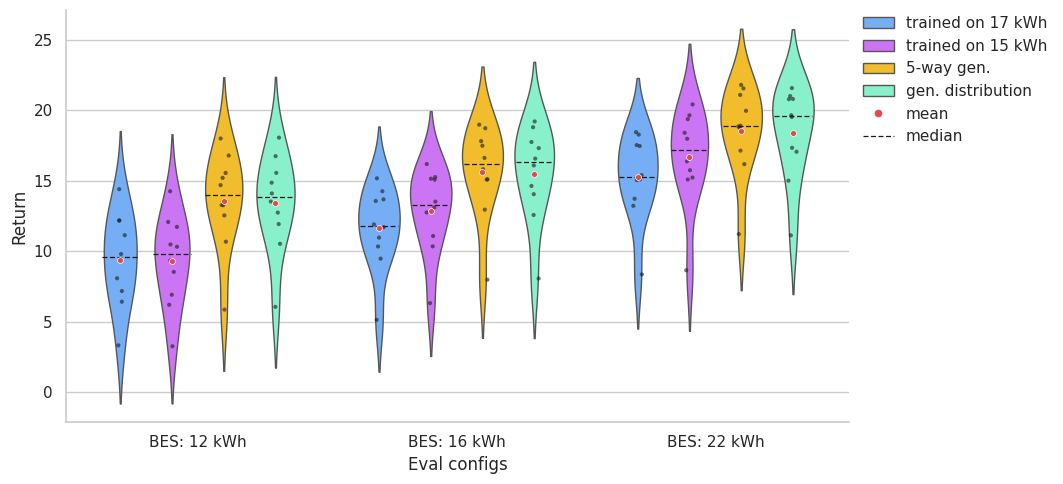

In [64]:
violin_for_metric("total_reward")

saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/3_gen_bat_cap_v1/20260813_134952_out_2.pdf  (cum_E_kWh)


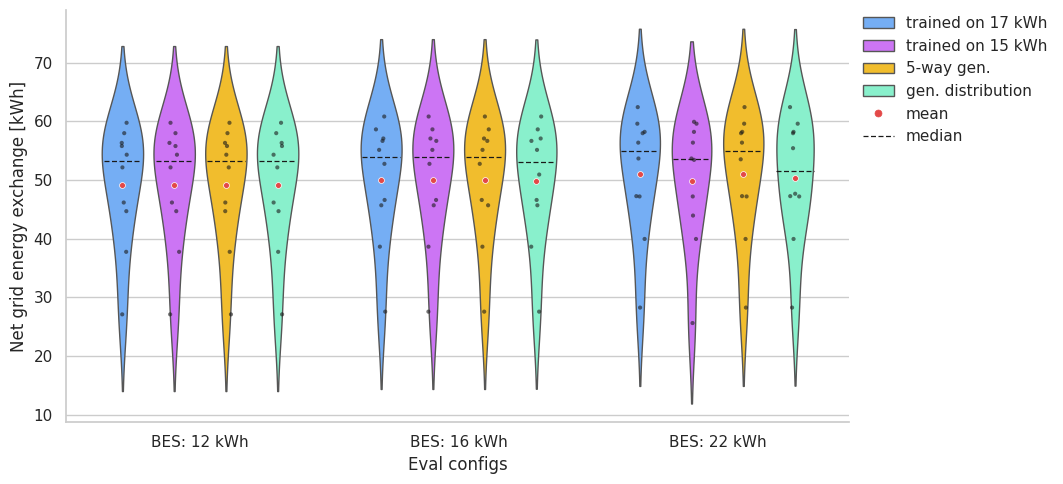

In [65]:
violin_for_metric("cum_E_kWh")

saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/3_gen_bat_cap_v1/20260813_134952_out_3.pdf  (cum_price_EUR)


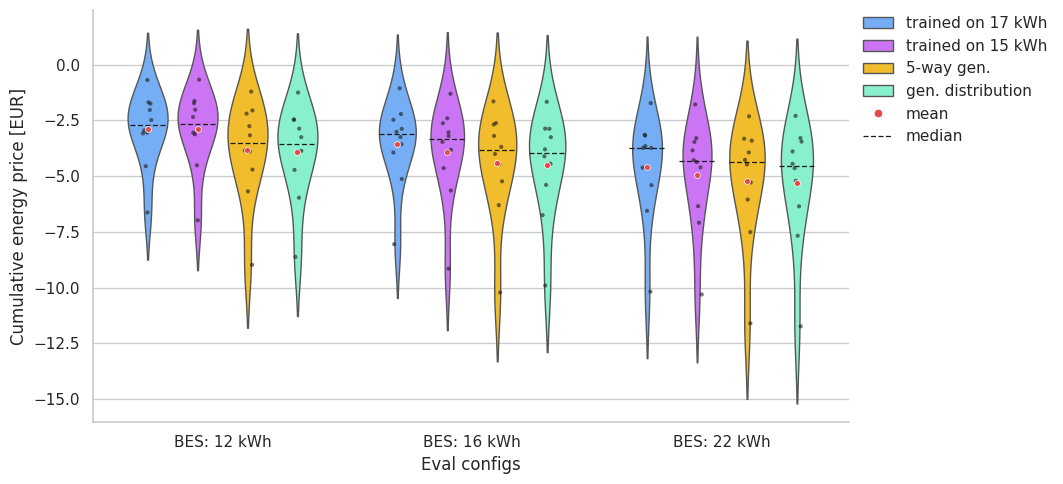

In [66]:
violin_for_metric("cum_price_EUR")

## Variance across eval configs, per source

For each source the metric mean is first taken within each held-out eval config, then those
config means are aggregated (`mean` / `std` / `median` / `min` / `max`) across configs — a small
`std` means the snapshot performs consistently over the held-out capacities.

**Result:** mean total reward is 11.59 (5-way), 11.54 (15 kWh), 11.00 (sampled) and 10.91
(17 kWh); the per-episode capacity sampler has the smallest spread across configs (std 1.26)
and the fixed 15 kWh run the largest (1.77). All sources gain reward as the held-out capacity
grows from 12 to 22 kWh.

In [67]:
present_metrics = [metric for metric in METRICS if metric in episodes.columns]
cfg_means = episodes.groupby(["source", "eval_cfg"])[present_metrics].mean()
cfg_means.groupby("source").agg(["mean", "std", "median", "min", "max"])

total_reward                                             \
                          mean       std     median        min        max   
source                                                                      
5-way gen.           15.934459  2.495441  15.661210  13.586888  18.555279   
gen. distribution    15.772991  2.503481  15.509570  13.411637  18.397766   
trained on 15 kWh    12.960614  3.697013  12.879267   9.304946  16.697630   
trained on 17 kWh    12.092714  2.958347  11.616881   9.401125  15.260137   

                   cum_E_kWh                                             \
                        mean       std     median        min        max   
source                                                                    
5-way gen.         50.067632  0.942069  49.946428  49.192031  51.064437   
gen. distribution  49.779697  0.595626  49.764084  49.192031  50.382977   
trained on 15 kWh  49.639114  0.396144  49.778884  49.192031  49.946428   
trained on 17 kWh  50.072160  0.949261  49.946428  49.192031  51.078022   

                  cum_price_EUR                                          
                           mean       std    median       min       max  
source                                                                   
5-way gen.            -4.489551  0.688119 -4.403925 -5.216475 -3.848252  
gen. distribution     -4.580103  0.684669 -4.504935 -5.299255 -3.936120  
trained on 15 kWh     -3.921253  1.020622 -3.927059 -4.938959 -2.897740  
trained on 17 kWh     -3.678448  0.859373 -3.555855 -4.592534 -2.886955

## Per-violin statistics

One row per (eval config, source) — i.e. per violin drawn above — over that violin's episodes:
`mean` (the red dot), `std`, `median` (the dashed line), `min` and `max` for every metric. Rows
follow the plot order: x-axis configs first, then the `SOURCES` hue order within each config.

In [68]:
present_metrics = [metric for metric in METRICS if metric in episodes.columns]
violin_stats = episodes.groupby(["eval_cfg", "source"])[present_metrics].agg(
    ["mean", "std", "median", "min", "max"]
)
# Match the plot order: x-axis configs (numeric), then the SOURCES hue order per config.
violin_stats = violin_stats.reindex(eval_cfg_order, level="eval_cfg").reindex(source_labels, level="source")
violin_stats

total_reward                                  \
                                   mean       std     median        min   
eval_cfg source                                                           
eval_1   trained on 17 kWh     9.401125  3.274992   9.576461   3.305740   
         trained on 15 kWh     9.304946  3.219315   9.826465   3.243512   
         5-way gen.           13.586888  3.452072  13.983998   5.848026   
         gen. distribution    13.411637  3.422389  13.815441   6.042354   
eval_2   trained on 17 kWh    11.616881  2.920008  11.801018   5.117170   
         trained on 15 kWh    12.879267  2.981296  13.312348   6.308659   
         5-way gen.           15.661210  3.276329  16.225972   7.973370   
         gen. distribution    15.509570  3.358373  16.336236   8.058727   
eval_3   trained on 17 kWh    15.260137  3.051482  15.253261   8.349631   
         trained on 15 kWh    16.697630  3.416604  17.186222   8.644119   
         5-way gen.           18.555279  3.162804  18.890990  11.212106   
         gen. distribution    18.397766  3.314009  19.596485  11.126965   

                                       cum_E_kWh                        \
                                  max       mean        std     median   
eval_cfg source                                                          
eval_1   trained on 17 kWh  14.408282  49.192031  10.356775  53.217811   
         trained on 15 kWh  14.255573  49.192031  10.356775  53.217811   
         5-way gen.         18.007365  49.192031  10.356775  53.217811   
         gen. distribution  18.070546  49.192031  10.356775  53.217811   
eval_2   trained on 17 kWh  15.176246  49.946428  10.443800  53.932453   
         trained on 15 kWh  16.191715  49.946428  10.443800  53.932453   
         5-way gen.         18.989639  49.946428  10.443800  53.932453   
         gen. distribution  19.218748  49.764084  10.405376  53.020735   
eval_3   trained on 17 kWh  18.459305  51.078022  10.581166  55.004415   
         trained on 15 kWh  20.430414  49.778884  10.862506  53.535815   
         5-way gen.         21.816158  51.064437  10.577579  54.936491   
         gen. distribution  21.591043  50.382977  10.534967  51.529190   

                                                 cum_price_EUR            \
                                  min        max          mean       std   
eval_cfg source                                                            
eval_1   trained on 17 kWh  27.102668  59.738004     -2.886955  1.678881   
         trained on 15 kWh  27.102668  59.738004     -2.897740  1.776150   
         5-way gen.         27.102668  59.738004     -3.848252  2.237671   
         gen. distribution  27.102668  59.738004     -3.936120  2.106249   
eval_2   trained on 17 kWh  27.564449  60.804940     -3.555855  1.913311   
         trained on 15 kWh  27.564449  60.804940     -3.927059  2.191890   
         5-way gen.         27.564449  60.804940     -4.403925  2.451472   
         gen. distribution  27.564449  60.804940     -4.504935  2.372748   
eval_3   trained on 17 kWh  28.257121  62.405343     -4.592534  2.368878   
         trained on 15 kWh  25.621591  59.901655     -4.938959  2.413163   
         5-way gen.         28.257121  62.405343     -5.216475  2.691371   
         gen. distribution  28.257121  62.405343     -5.299255  2.746980   

                                                           
                              median        min       max  
eval_cfg source                                            
eval_1   trained on 17 kWh -2.709625  -6.630820 -0.681368  
         trained on 15 kWh -2.637749  -6.981537 -0.668542  
         5-way gen.        -3.507642  -8.981276 -1.205376  
         gen. distribution -3.556705  -8.625205 -1.245430  
eval_2   trained on 17 kWh -3.127622  -8.056036 -1.054734  
         trained on 15 kWh -3.329360  -9.152082 -1.300320  
         5-way gen.        -3.846257 -10.223519 -1.643444  
         gen. distribution -3.951779  -9.907083 -